In [3]:
import pandas as pd
df1=pd.read_csv('Datasets/house-prices-advanced-regression-techniques/train.csv')
df1.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Exploratory Data Analysis

In [4]:
df1.shape

(1460, 81)

In [5]:
df1.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [6]:
dty=df1.dtypes
print(dty.array)

<NumpyExtensionArray>
[  dtype('int64'),   dtype('int64'),       dtype('O'), dtype('float64'),
   dtype('int64'),       dtype('O'),       dtype('O'),       dtype('O'),
       dtype('O'),       dtype('O'),       dtype('O'),       dtype('O'),
       dtype('O'),       dtype('O'),       dtype('O'),       dtype('O'),
       dtype('O'),   dtype('int64'),   dtype('int64'),   dtype('int64'),
   dtype('int64'),       dtype('O'),       dtype('O'),       dtype('O'),
       dtype('O'),       dtype('O'), dtype('float64'),       dtype('O'),
       dtype('O'),       dtype('O'),       dtype('O'),       dtype('O'),
       dtype('O'),       dtype('O'),   dtype('int64'),       dtype('O'),
   dtype('int64'),   dtype('int64'),   dtype('int64'),       dtype('O'),
       dtype('O'),       dtype('O'),       dtype('O'),   dtype('int64'),
   dtype('int64'),   dtype('int64'),   dtype('int64'),   dtype('int64'),
   dtype('int64'),   dtype('int64'),   dtype('int64'),   dtype('int64'),
   dtype('int64'),       dtyp

In [7]:
def treat_na(df,col):
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col]=df[col].fillna(df[col].mean())
    return df

In [8]:
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns

In [9]:
for col in df1.columns:
    df2=treat_na(df1,col)

In [10]:
df2[[col for col in df2.columns if pd.api.types.is_integer_dtype(df2[col])]].isnull().sum()

Id               0
MSSubClass       0
LotArea          0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
BsmtFinSF1       0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
TotRmsAbvGrd     0
Fireplaces       0
GarageCars       0
GarageArea       0
WoodDeckSF       0
OpenPorchSF      0
EnclosedPorch    0
3SsnPorch        0
ScreenPorch      0
PoolArea         0
MiscVal          0
MoSold           0
YrSold           0
SalePrice        0
dtype: int64

In [11]:
isnull=df2.isnull().sum()

In [13]:
isnull.where(isnull>700).dropna()

Alley          1369.0
MasVnrType      872.0
PoolQC         1453.0
Fence          1179.0
MiscFeature    1406.0
dtype: float64

In [16]:
df2.drop(columns=['Alley','PoolQC','Fence','MiscFeature','MasVnrType'],inplace=True)

KeyError: "['MasVnrType'] not found in axis"

In [17]:
df2.shape

(1460, 76)

In [18]:
df2.dropna(thresh=20,inplace=True)

In [19]:
df2.shape

(1460, 76)

In [20]:
isnull_obj=df2[[col for col in df2.columns if pd.api.types.is_object_dtype(df2[col])]].isnull().sum() #df2.select_dtypes(include=['object'].isnull().sum()

In [21]:
null_columns=isnull_obj.where(isnull_obj>0).dropna().index

In [22]:
df2[null_columns].head()

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Electrical,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond
0,Gd,TA,No,GLQ,Unf,SBrkr,NaN,Attchd,RFn,TA,TA
1,Gd,TA,Gd,ALQ,Unf,SBrkr,TA,Attchd,RFn,TA,TA
2,Gd,TA,Mn,GLQ,Unf,SBrkr,TA,Attchd,RFn,TA,TA
3,TA,Gd,No,ALQ,Unf,SBrkr,Gd,Detchd,Unf,TA,TA
4,Gd,TA,Av,GLQ,Unf,SBrkr,TA,Attchd,RFn,TA,TA


In [50]:
df2[null_columns].tail()
df2['FireplaceQu']=df3.apply(lambda x: x['BsmtCond'] if pd.isnull(x['FireplaceQu'])
                             else x['FireplaceQu'],axis=1)
df2.FireplaceQu.isnull().sum()

np.int64(0)

In [51]:
def treat_na_obj(df,col):
    if pd.api.types.is_object_dtype(df[col]):
        mod_val=df[col].value_counts().index[0]
        df[col]=df[col].fillna(mod_val)
    return df

In [52]:
for col in df2.columns:
    df3=treat_na_obj(df2,col)


In [53]:
df3.select_dtypes(include=['object']).isnull().sum()

MSZoning         0
Street           0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Condition2       0
BldgType         0
HouseStyle       0
RoofStyle        0
RoofMatl         0
Exterior1st      0
Exterior2nd      0
ExterQual        0
ExterCond        0
Foundation       0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
BsmtFinType1     0
BsmtFinType2     0
Heating          0
HeatingQC        0
CentralAir       0
Electrical       0
KitchenQual      0
Functional       0
FireplaceQu      0
GarageType       0
GarageFinish     0
GarageQual       0
GarageCond       0
PavedDrive       0
SaleType         0
SaleCondition    0
dtype: int64

## outlier removal

In [54]:
df_num=df3.select_dtypes(include=['integer','float'])

In [55]:
df_num.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,61,0,0,0,0,0,2,2008,208500
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,298,0,0,0,0,0,0,5,2007,181500
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,42,0,0,0,0,0,9,2008,223500
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,35,272,0,0,0,0,2,2006,140000
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,192,84,0,0,0,0,0,12,2008,250000


<Axes: xlabel='MasVnrArea', ylabel='Count'>

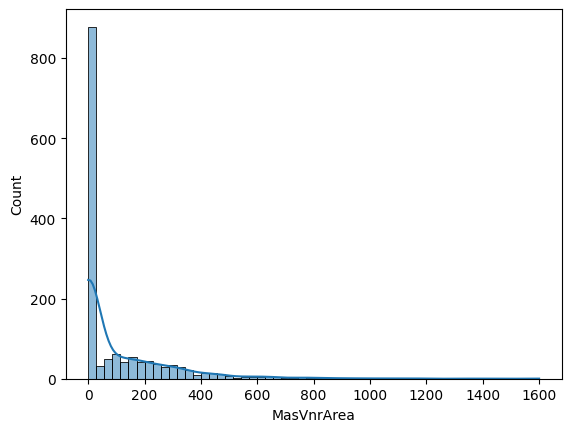

In [56]:
import seaborn as sns
sns.histplot(data=df_num,x='MasVnrArea',kde=True)

In [57]:
df_num.YearBuilt.describe()

count    1460.000000
mean     1971.267808
std        30.202904
min      1872.000000
25%      1954.000000
50%      1973.000000
75%      2000.000000
max      2010.000000
Name: YearBuilt, dtype: float64

In [58]:
from matplotlib import pyplot as plt
def remove_outlier(df,col):
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    df=df[(df[col]>=q1-1.5*iqr)&(df[col]<=q3+1.5*iqr)]
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col} after outlier removal")
    plt.show()
    return df

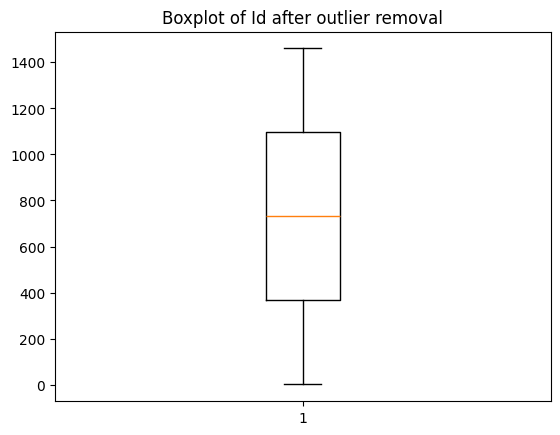

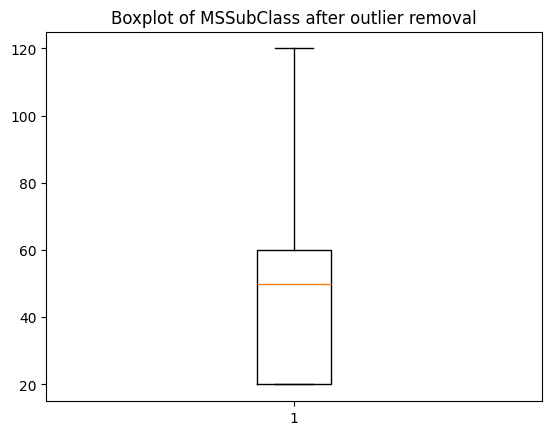

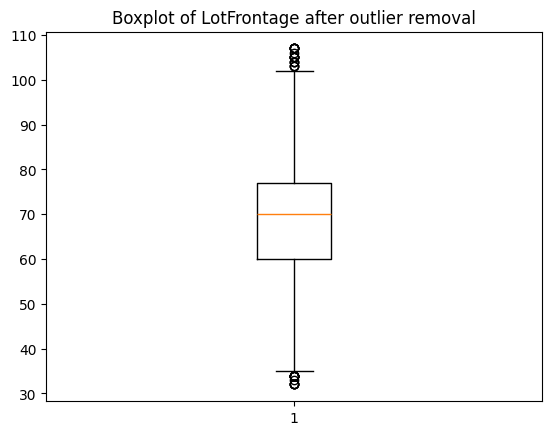

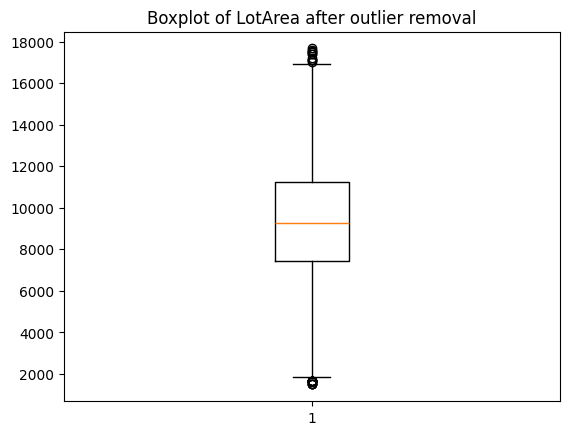

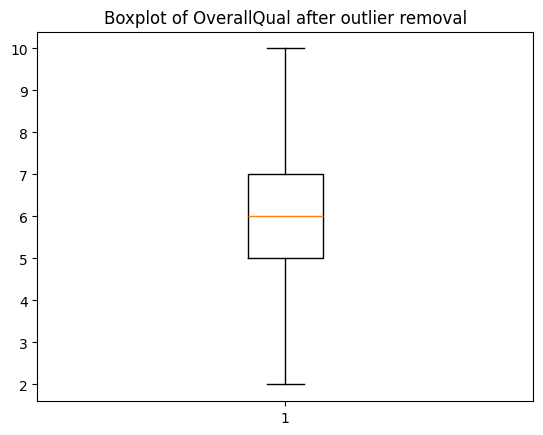

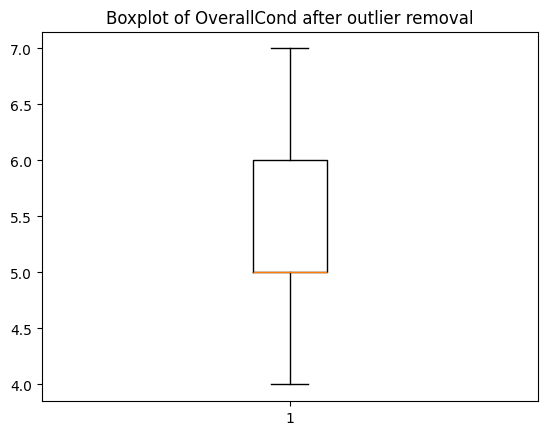

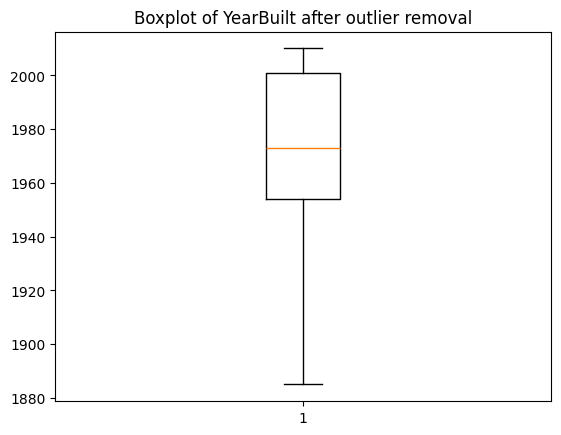

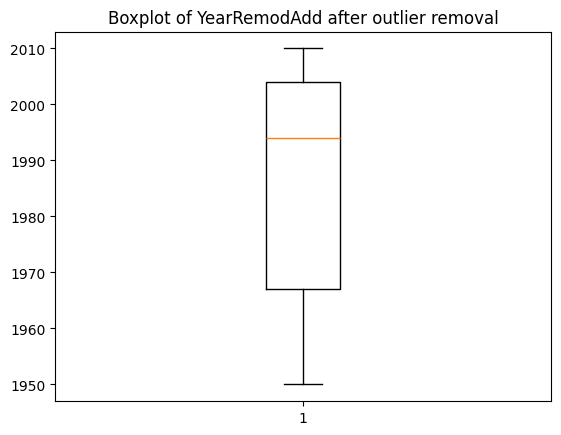

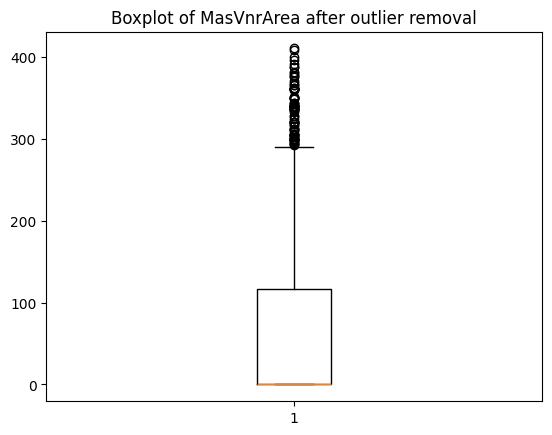

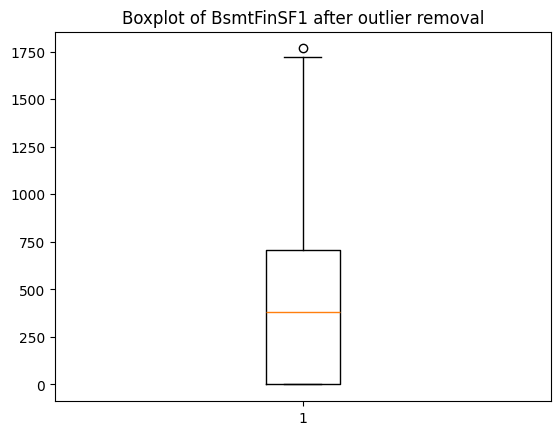

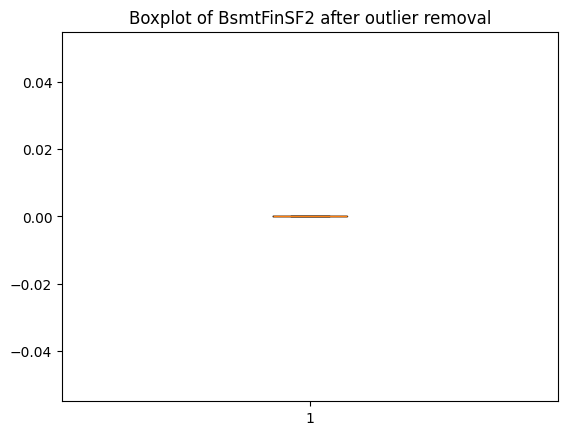

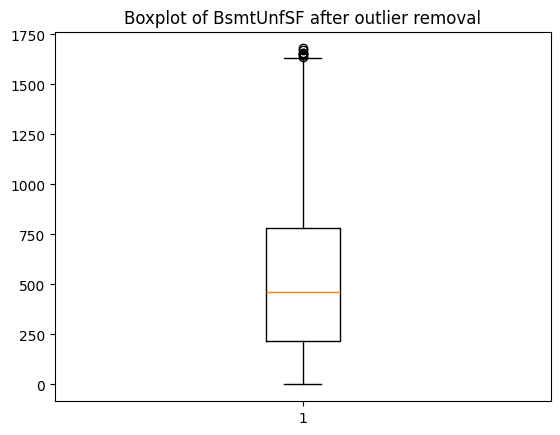

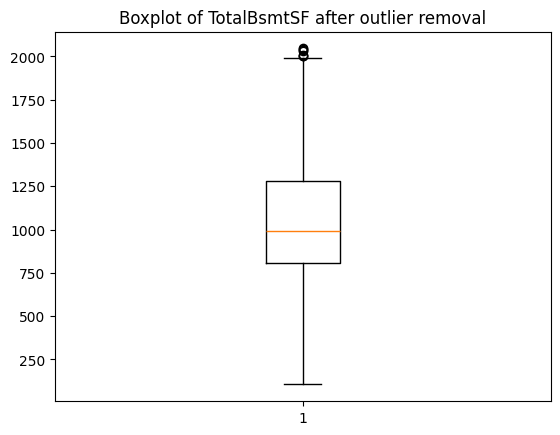

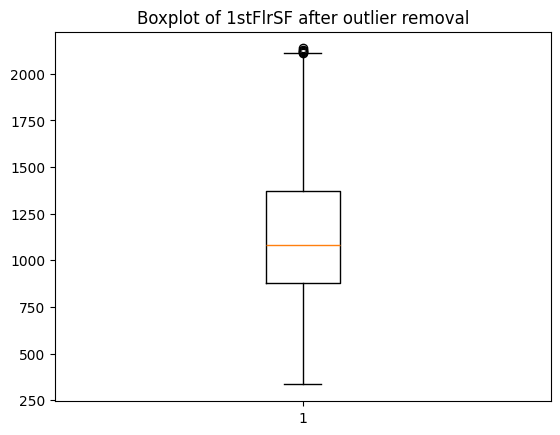

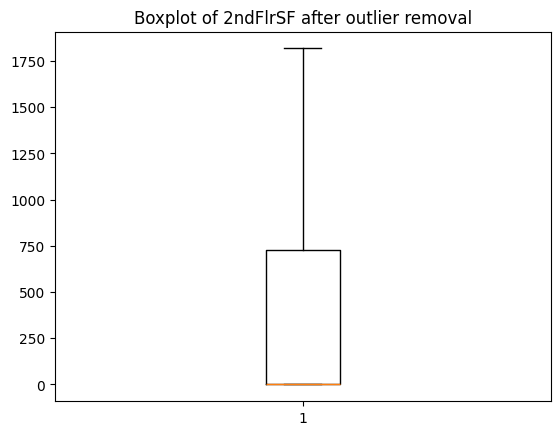

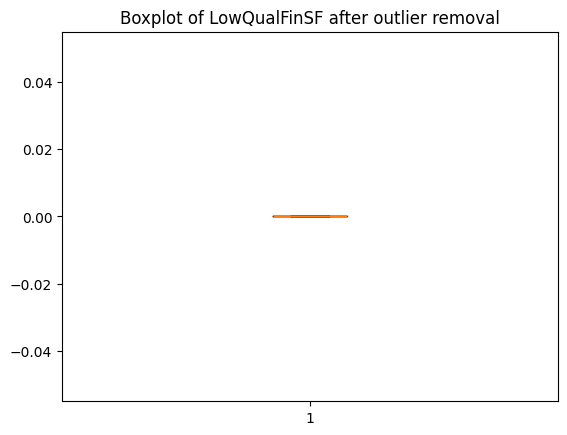

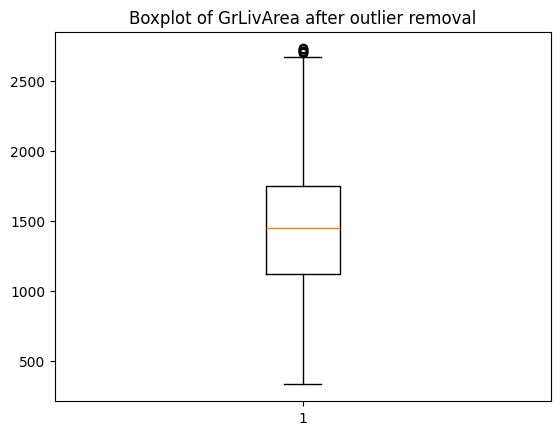

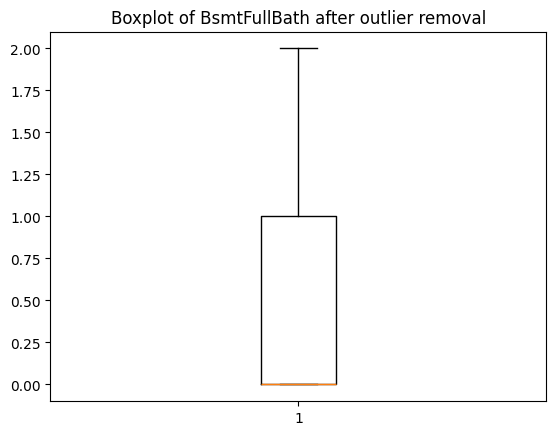

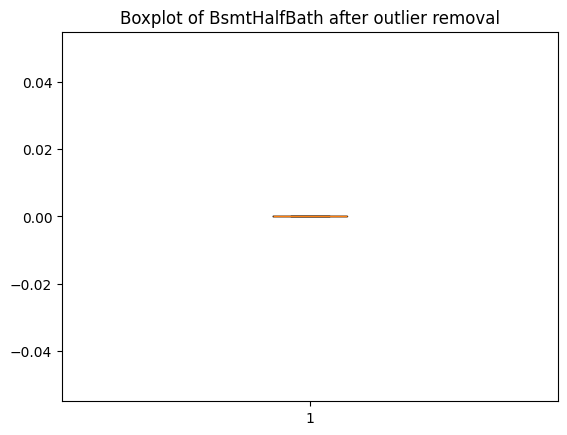

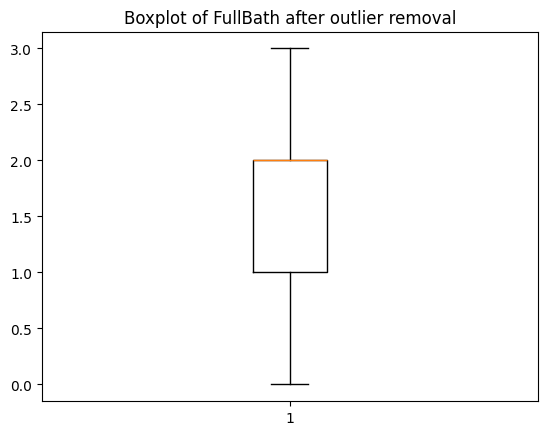

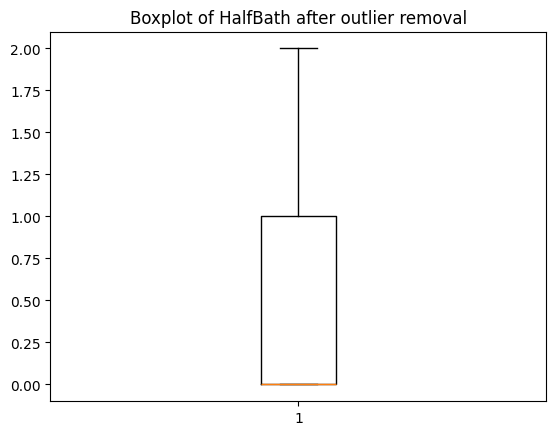

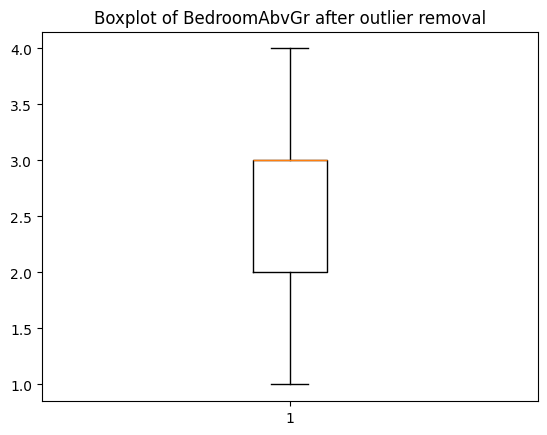

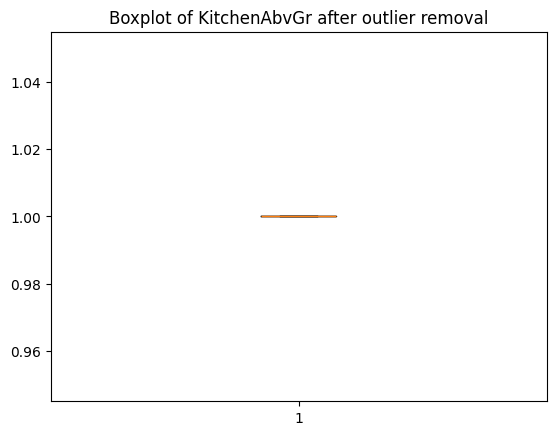

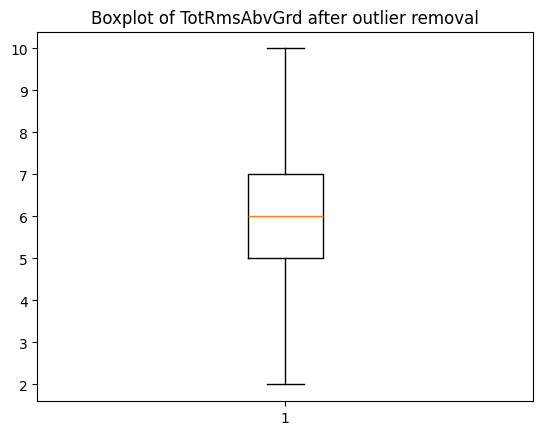

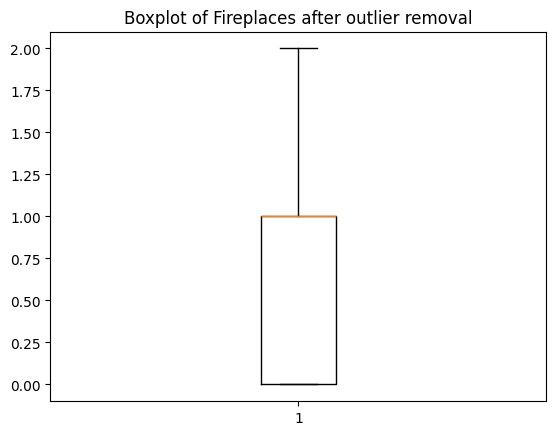

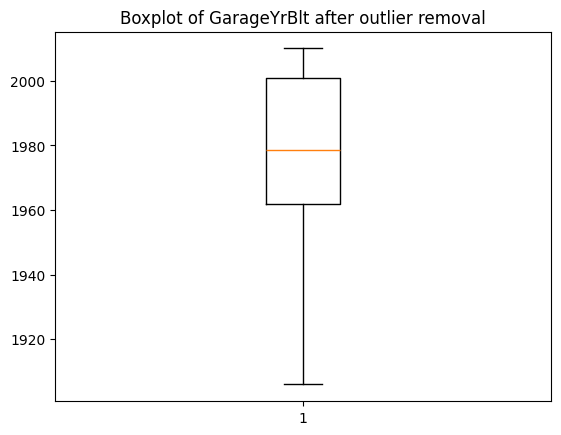

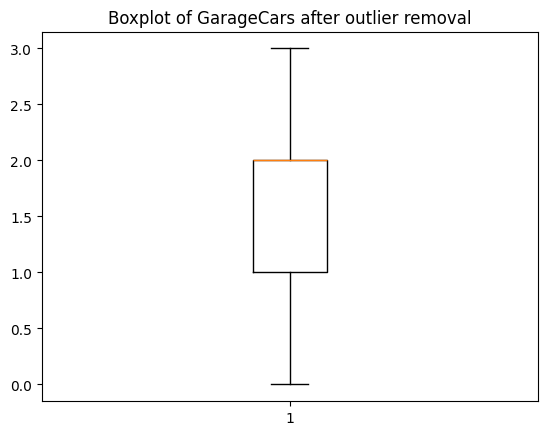

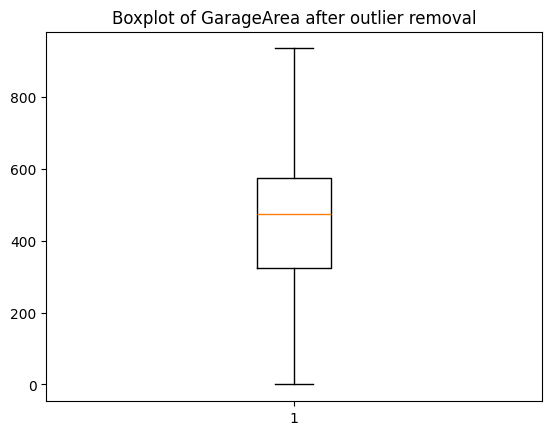

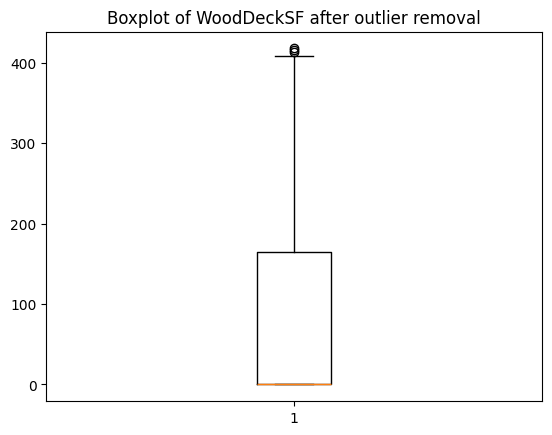

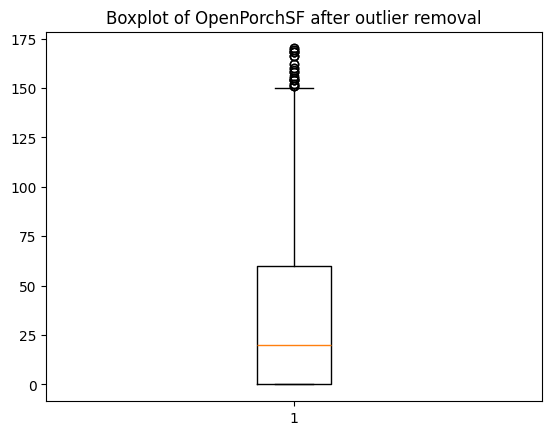

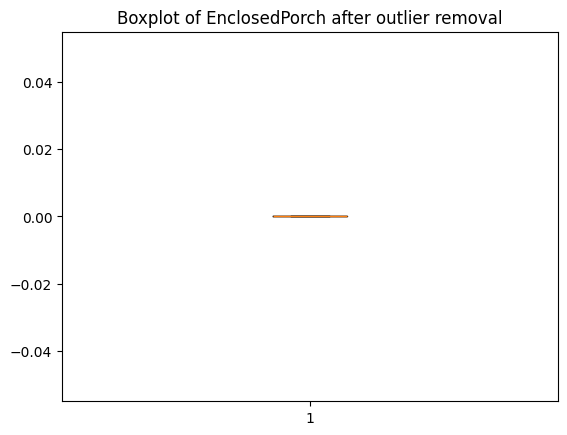

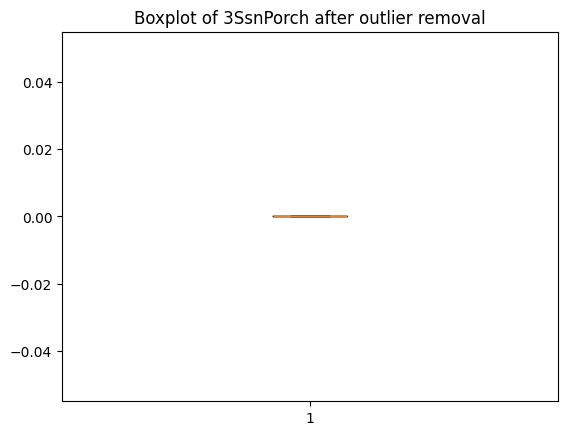

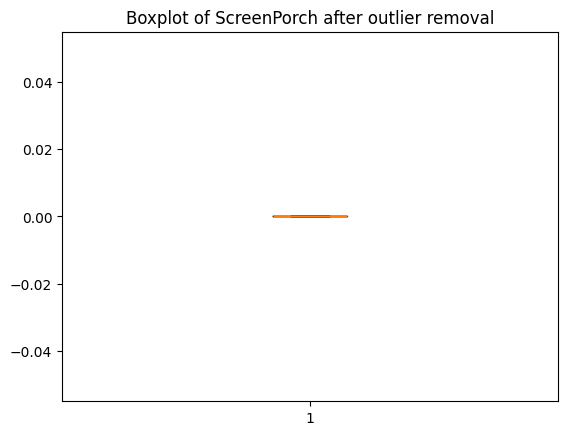

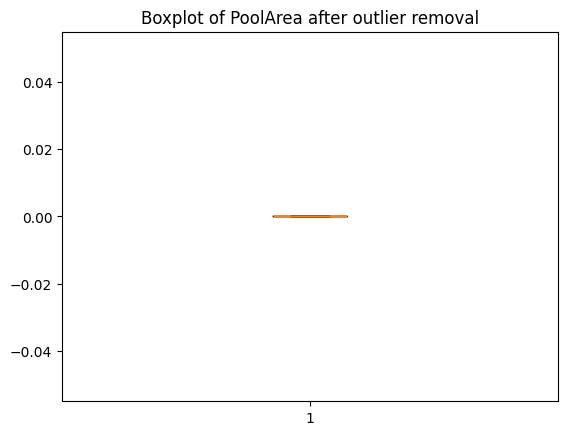

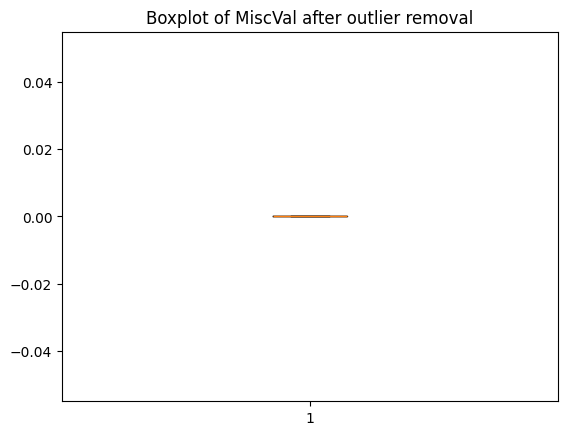

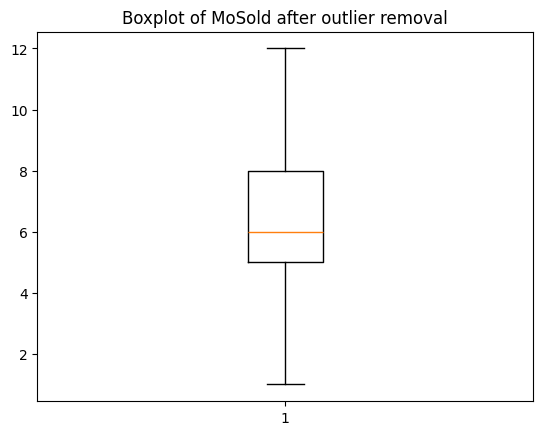

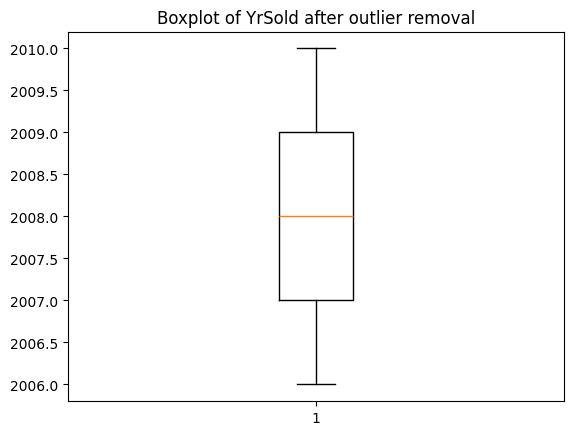

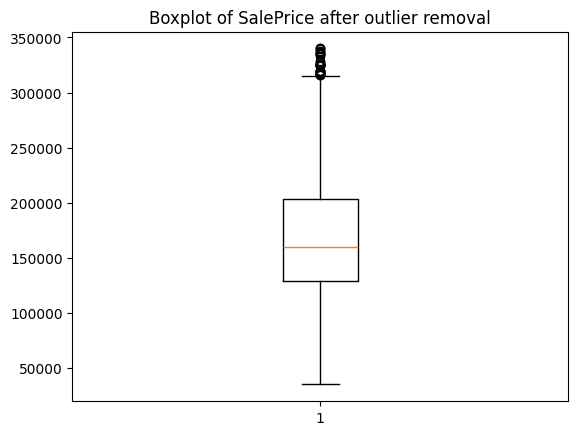

In [59]:
for col in df_num.columns:
    if col != 'SalesPrice':
        df_num1=remove_outlier(df_num,col)

In [61]:
df_num1.describe()
y=df_num.SalePrice

In [62]:

from sklearn.preprocessing import StandardScaler
df_num1.drop('Id',axis=1,inplace=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num1)


C:\Users\user\AppData\Local\Temp\ipykernel_11636\572125097.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_num1.drop('Id',axis=1,inplace=True)


In [63]:
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.01)  # threshold=0 removes only constant features
X_selected = selector.fit_transform(X_scaled)
# Get selected feature names
selected_features = df_num1.columns[selector.get_support()]
selec=selected_features.tolist()

In [64]:
df_sec=pd.DataFrame(X_scaled,columns=df_num1.columns)
df_num2=df_sec[selec]
df_num2.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,0.058720,-0.197041,-0.204916,0.792970,-0.528822,1.097354,0.917091,0.664969,0.674064,-0.292015,...,-0.736078,0.245191,-0.364272,-0.113179,-0.267373,-0.064858,-0.089594,-1.595626,0.135712,0.646235
1,-0.876115,0.500033,-0.066726,0.012826,2.154935,0.197316,-0.390176,-0.567437,1.309209,-0.292015,...,1.711462,-0.683336,-0.364272,-0.113179,-0.267373,-0.064858,-0.089594,-0.485591,-0.617704,0.190222
2,0.058720,-0.057626,0.131547,0.792970,-0.528822,1.030684,0.868673,0.451184,0.160344,-0.292015,...,-0.736078,-0.044022,-0.364272,-0.113179,-0.267373,-0.064858,-0.089594,0.994456,0.135712,0.899575
3,0.292428,-0.429398,-0.072734,0.792970,-0.528822,-1.836103,-0.680680,-0.567437,-0.470131,-0.292015,...,-0.736078,-0.150575,4.063351,-0.113179,-0.267373,-0.064858,-0.089594,-1.595626,-1.371121,-0.510685
4,0.058720,0.685920,0.493245,1.573115,-0.528822,0.997350,0.771839,1.633287,0.554974,-0.292015,...,0.840860,0.595291,-0.364272,-0.113179,-0.267373,-0.064858,-0.089594,2.104491,0.135712,1.347142


In [65]:
import numpy as np
corr_matrix = df_num2.corr().abs()   # absolute correlation values
# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# Find features with correlation > 0.9
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
# Drop them
df_red = df_num2.drop(columns=to_drop)
print("Dropped features:", to_drop)
print("Remaining features:", df_red.columns.tolist())

Dropped features: ['GarageArea']
Remaining features: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']


In [66]:
df_red.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,0.058720,-0.197041,-0.204916,0.792970,-0.528822,1.097354,0.917091,0.664969,0.674064,-0.292015,...,-0.736078,0.245191,-0.364272,-0.113179,-0.267373,-0.064858,-0.089594,-1.595626,0.135712,0.646235
1,-0.876115,0.500033,-0.066726,0.012826,2.154935,0.197316,-0.390176,-0.567437,1.309209,-0.292015,...,1.711462,-0.683336,-0.364272,-0.113179,-0.267373,-0.064858,-0.089594,-0.485591,-0.617704,0.190222
2,0.058720,-0.057626,0.131547,0.792970,-0.528822,1.030684,0.868673,0.451184,0.160344,-0.292015,...,-0.736078,-0.044022,-0.364272,-0.113179,-0.267373,-0.064858,-0.089594,0.994456,0.135712,0.899575
3,0.292428,-0.429398,-0.072734,0.792970,-0.528822,-1.836103,-0.680680,-0.567437,-0.470131,-0.292015,...,-0.736078,-0.150575,4.063351,-0.113179,-0.267373,-0.064858,-0.089594,-1.595626,-1.371121,-0.510685
4,0.058720,0.685920,0.493245,1.573115,-0.528822,0.997350,0.771839,1.633287,0.554974,-0.292015,...,0.840860,0.595291,-0.364272,-0.113179,-0.267373,-0.064858,-0.089594,2.104491,0.135712,1.347142


In [67]:
df_cat=df3.select_dtypes(include=['object'])
df_cat.head()

,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,...,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
0,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
1,RL,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
2,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
3,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,...,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,WD,Abnorml
4,RL,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal


In [68]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)
cat_encoded = encoder.fit_transform(df_cat)
cat_df = pd.DataFrame(cat_encoded, columns=encoder.get_feature_names_out(df_cat.columns))
cat_df.head()

,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [69]:
df_cat = cat_df.loc[df_red.index]
df_cat.shape

(1399, 197)

In [70]:
y=y.loc[df_red.index]
y.shape

(1399,)

In [71]:
df_final = pd.concat([df_red,df_cat], axis=1)

In [72]:
df_final.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0.058720,-0.197041,-0.204916,0.792970,-0.528822,1.097354,0.917091,0.664969,0.674064,-0.292015,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,-0.876115,0.500033,-0.066726,0.012826,2.154935,0.197316,-0.390176,-0.567437,1.309209,-0.292015,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.058720,-0.057626,0.131547,0.792970,-0.528822,1.030684,0.868673,0.451184,0.160344,-0.292015,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.292428,-0.429398,-0.072734,0.792970,-0.528822,-1.836103,-0.680680,-0.567437,-0.470131,-0.292015,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.058720,0.685920,0.493245,1.573115,-0.528822,0.997350,0.771839,1.633287,0.554974,-0.292015,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [73]:
from sklearn.decomposition import PCA
pca = PCA(0.96)
X_pca=pca.fit_transform(df_final,y)
X_pca.shape

(1399, 76)

In [82]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import BaggingRegressor
from sklearn.model_selection import RandomizedSearchCV
lasso = Lasso(random_state=42, max_iter=10000)
ridge = Ridge(random_state=42)
bagging_lasso = BaggingRegressor(estimator=lasso, random_state=42)
bagging_ridge = BaggingRegressor(estimator=ridge, random_state=42)
from sklearn.ensemble import RandomForestRegressor
rforest= RandomForestRegressor(random_state=42)

In [79]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df_final,y,test_size=0.3,random_state=30)

In [83]:
import numpy as np
param_distributions = [
    {
        'estimator': [lasso],
        'n_estimators': [10, 50, 100],
        'max_samples': np.linspace(0.5, 1.0, 6),   # sample fractions between 0.5 and 1.0
        'estimator__alpha': np.logspace(-3, 2, 20) # regularization strength for Lasso
    },
    {
        'estimator': [ridge],
        'n_estimators': [10, 50, 100],
        'max_samples': np.linspace(0.5, 1.0, 6),
        'estimator__alpha': np.logspace(-3, 2, 20) # regularization strength for Ridge
    },
    {
        'estimator': [rforest],
        'n_estimators': [50, 100, 200],
        'estimator__max_depth': [None, 5, 10, 20],
        'estimator__max_features': ['sqrt', 'log2', None]
    }
]

# RandomizedSearchCV setup
random_search = RandomizedSearchCV(
    estimator=BaggingRegressor(random_state=42),
    param_distributions=param_distributions,
    n_iter=30,          # number of random combinations to try
    cv=3,               # fewer folds for speed
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

# Fit
random_search.fit(X_train, y_train)

print("Best model:", random_search.best_estimator_)
print("Best params:", random_search.best_params_)
print("Best score:", random_search.best_score_)


KeyboardInterrupt: 